# Равносильность условий на координаты

Из первого: $u_1 v_1 = -v_2 u_2$. Переносим влево: $u_1 v_1 + v_2 u_2 = 0$. Поскольку $v_2 u_2 = u_2 v_2$, получаем $u_1 v_1 + u_2 v_2 = 0$.

Из второго: $u_2 v_2 = -v_1 u_1$ даёт то же самое после переноса и $v_1 u_1 = u_1 v_1$.

Равносильность:

$$u_1 v_1 = -v_2 u_2 \;\text{ и }\; u_2 v_2 = -v_1 u_1 \quad \Leftrightarrow \quad u_1 v_1 + u_2 v_2 = 0$$

Вывод по шагам:

$$u_1 v_1 = -v_2 u_2 \quad\Rightarrow\quad u_1 v_1 + v_2 u_2 = 0 \quad\Rightarrow\quad u_1 v_1 + u_2 v_2 = 0$$

## Обозначение минора матрицы

Минор — определитель квадратной подматрицы, полученной вычёркиванием части строк и столбцов.

**Полная запись:** минор из строк с номерами $i_1, i_2, \ldots, i_k$ и столбцов с номерами $j_1, j_2, \ldots, j_k$ обозначается

$$M_{i_1,\,i_2,\,\ldots,\,i_k}^{j_1,\,j_2,\,\ldots,\,j_k}$$

**Кратко:** $M_{i_1\ldots i_k}^{j_1\ldots j_k}$.

### Что отражает минор (смысл минора)

**Геометрия:** Минор порядка $k$ из каких-то $k$ столбцов и $k$ строк — это **ориентированный $k$-мерный объём** параллелепипеда, натянутого на эти $k$ столбцов, в подпространстве выбранных координат (строк).  
Например, минор $2\times2$ — площадь параллелограмма на двух векторах-столбцах в плоскости двух выбранных координат; минор $3\times3$ — объём параллелепипеда на трёх столбцах.

**Алгебра:** Набор из $k$ столбцов линейно независим тогда и только тогда, когда **хотя бы один** минор порядка $k$ из этих столбцов (при каком-то наборе $k$ строк) **не равен нулю**.  
**Ранг матрицы** равен максимальному порядку ненулевого минора.

**Кофакторы:** Алгебраическое дополнение $A_{ij} = (-1)^{i+j} M_{ij}$ (минор после вычёркивания строки $i$ и столбца $j$) входит в формулу обратной матрицы и правило Крамера — там минор показывает «вклад» пары (строка, столбец) в определитель.

### Примеры с картинками: миноры матрицы $3\times 3$

Ниже — матрица $A$ размера $3\times 3$. Минор порядка 2: выбираем две строки и два столбца, берём определитель подматрицы. Геометрически это **площадь параллелограмма** на двух соответствующих столбцах в плоскости выбранных координат (выбранных строк).

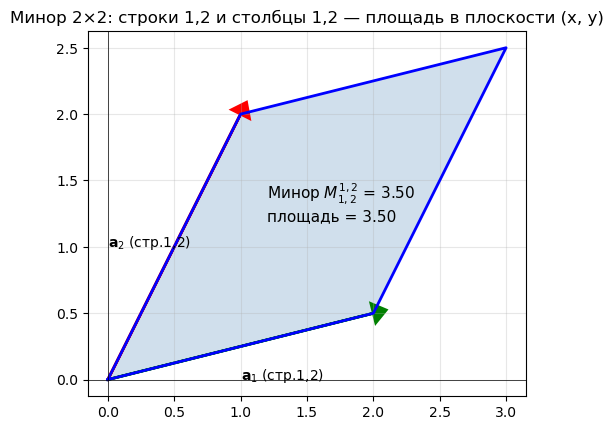

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Матрица 3×3 (столбцы — векторы a1, a2, a3)
A = np.array([[2,  1, 0.5],
              [0.5, 2, 0],
              [0,   0, 1.5]])

# Минор M^{1,2}_{1,2}: строки 1,2 и столбцы 1,2 (индексы 0,1)
# Подматрица из первых двух строк и первых двух столбцов
M12_12 = A[:2, :2]   # строки 0,1 и столбцы 0,1
minor_val = np.linalg.det(M12_12)
# Два столбца в координатах (x, y) — первые две компоненты a1 и a2
v1 = A[:2, 0]   # (2, 0.5)
v2 = A[:2, 1]   # (1, 2)
area_xy = abs(minor_val)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_aspect('equal')
pts = np.array([[0, 0], v1, v1 + v2, v2, [0, 0]])
ax.plot(pts[:, 0], pts[:, 1], 'b-', linewidth=2)
ax.fill(pts[:-1, 0], pts[:-1, 1], alpha=0.25, color='steelblue')
ax.arrow(0, 0, v1[0], v1[1], head_width=0.15, head_length=0.1, fc='green', ec='green', linewidth=2)
ax.arrow(0, 0, v2[0], v2[1], head_width=0.15, head_length=0.1, fc='red', ec='red', linewidth=2)
ax.text(v1[0]/2, v1[1]/2 - 0.25, r'$\mathbf{a}_1$ (стр.1,2)', fontsize=10)
ax.text(v2[0]/2 - 0.5, v2[1]/2, r'$\mathbf{a}_2$ (стр.1,2)', fontsize=10)
ax.text(1.2, 1.2, f'Минор $M_{{1,2}}^{{1,2}}$ = {minor_val:.2f}\nплощадь = {area_xy:.2f}', fontsize=11)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Минор 2×2: строки 1,2 и столбцы 1,2 — площадь в плоскости (x, y)')
plt.tight_layout()
plt.show()

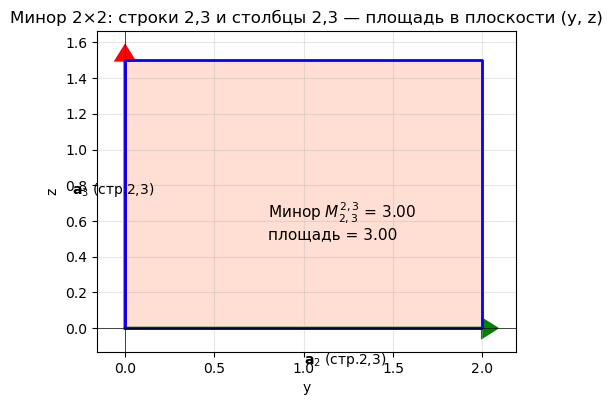

In [9]:
# Минор M^{2,3}_{2,3}: строки 2,3 и столбцы 2,3 (индексы 1,2)
# Подматрица из второй и третьей строк и столбцов
M23_23 = A[1:, 1:]   # строки 1,2 и столбцы 1,2
minor_23 = np.linalg.det(M23_23)
# В плоскости (y, z) — координаты 2 и 3 столбцов a2 и a3
w1 = A[1:, 1]   # (2, 0) из столбца a2
w2 = A[1:, 2]   # (0, 1.5) из столбца a3
area_yz = abs(minor_23)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_aspect('equal')
pts = np.array([[0, 0], w1, w1 + w2, w2, [0, 0]])
ax.plot(pts[:, 0], pts[:, 1], 'b-', linewidth=2)
ax.fill(pts[:-1, 0], pts[:-1, 1], alpha=0.25, color='coral')
ax.arrow(0, 0, w1[0], w1[1], head_width=0.1, head_length=0.08, fc='green', ec='green', linewidth=2)
ax.arrow(0, 0, w2[0], w2[1], head_width=0.1, head_length=0.08, fc='red', ec='red', linewidth=2)
ax.text(w1[0]/2, w1[1]/2 - 0.2, r'$\mathbf{a}_2$ (стр.2,3)', fontsize=10)
ax.text(w2[0]/2 - 0.3, w2[1]/2, r'$\mathbf{a}_3$ (стр.2,3)', fontsize=10)
ax.text(0.8, 0.5, f'Минор $M_{{2,3}}^{{2,3}}$ = {minor_23:.2f}\nплощадь = {area_yz:.2f}', fontsize=11)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('y')
ax.set_ylabel('z')
ax.grid(True, alpha=0.3)
ax.set_title('Минор 2×2: строки 2,3 и столбцы 2,3 — площадь в плоскости (y, z)')
plt.tight_layout()
plt.show()

---
## Зачем для определителя нужны миноры (итог)

**Геометрический смысл.** Определитель — ориентированный объём параллелепипеда на столбцах. Минор $M_{ij}$ — это **(n−1)-мерный ориентированный объём** «базы»: параллелепипед из всех столбцов, кроме $j$-го, в гиперплоскости «$i$-я координата = 0$» (проекция на остальные оси).

**Разложение по строке:** полный объём получается как сумма вкладов «высота × база»: для каждого столбца $j$ берём высоту $a_{ij}$ вдоль $i$-й оси и (n−1)-объём базы из остальных столбцов — это как раз $|M_{ij}|$ с правильным знаком.

**Почему знак $(-1)^{i+j}$?** Определитель — *ориентированный* объём: от перестановки строк/столбцов знак меняется. Чтобы поставить элемент $a_{ij}$ на место $(1,1)$, нужно сдвинуть строку $i$ вверх на $i-1$ шаг и столбец $j$ влево на $j-1$ шаг. Каждый шаг — одна перестановка, каждая перестановка меняет знак. Всего сдвигов: $(i-1)+(j-1) = i+j-2$, поэтому множитель перед минором: $(-1)^{i+j-2} = (-1)^{i+j}$.

### Пример в 3D: разложение по первой строке

Матрица $A$ размера $3\times 3$. Разложение по строке $i=1$:
$$\det A = a_{11} (-1)^{1+1} M_{11} + a_{12} (-1)^{1+2} M_{12} + a_{13} (-1)^{1+3} M_{13} = a_{11} M_{11} - a_{12} M_{12} + a_{13} M_{13}.$$

Ниже: конкретная матрица, вычисление каждого минора $M_{1j}$ (определитель подматрицы без строки 1 и столбца $j$), знаки и проверка суммы.

In [10]:
import numpy as np

# Матрица 3×3
A = np.array([[2,  1, 0.5],
              [0.5, 2, 0],
              [0,   0, 1.5]])

# Разложение по первой строке (i=1, индексы 0): det = a11*M11 - a12*M12 + a13*M13
# M1j = определитель матрицы без строки 1 и столбца j
M11 = np.linalg.det(A[1:, 1:])   # строки 2,3 и столбцы 2,3
M12 = np.linalg.det(A[1:, [0, 2]])  # строки 2,3 и столбцы 1,3
M13 = np.linalg.det(A[1:, :2])   # строки 2,3 и столбцы 1,2

a11, a12, a13 = A[0, 0], A[0, 1], A[0, 2]
term1 = a11 * (+1) * M11   # (-1)^(1+1) = +1
term2 = a12 * (-1) * M12   # (-1)^(1+2) = -1
term3 = a13 * (+1) * M13   # (-1)^(1+3) = +1

det_expansion = term1 + term2 + term3
det_direct = np.linalg.det(A)

print("Матрица A:")
print(A)
print("\nРазложение по строке 1: det A = a11·M11 − a12·M12 + a13·M13")
print(f"  M11 = det(подматрица без стр.1, столб.1) = {M11:.4f}")
print(f"  M12 = det(подматрица без стр.1, столб.2) = {M12:.4f}")
print(f"  M13 = det(подматрица без стр.1, столб.3) = {M13:.4f}")
print(f"\n  a11·M11 = {a11} · {M11:.4f} = {term1:.4f}")
print(f"  −a12·M12 = −{a12} · {M12:.4f} = {term2:.4f}")
print(f"  a13·M13 = {a13} · {M13:.4f} = {term3:.4f}")
print(f"\n  Сумма (разложение): {det_expansion:.4f}")
print(f"  det(A) напрямую:     {det_direct:.4f}")
print(f"  Совпадают: {np.isclose(det_expansion, det_direct)}")

Матрица A:
[[2.  1.  0.5]
 [0.5 2.  0. ]
 [0.  0.  1.5]]

Разложение по строке 1: det A = a11·M11 − a12·M12 + a13·M13
  M11 = det(подматрица без стр.1, столб.1) = 3.0000
  M12 = det(подматрица без стр.1, столб.2) = 0.7500
  M13 = det(подматрица без стр.1, столб.3) = 0.0000

  a11·M11 = 2.0 · 3.0000 = 6.0000
  −a12·M12 = −1.0 · 0.7500 = -0.7500
  a13·M13 = 0.5 · 0.0000 = 0.0000

  Сумма (разложение): 5.2500
  det(A) напрямую:     5.2500
  Совпадают: True


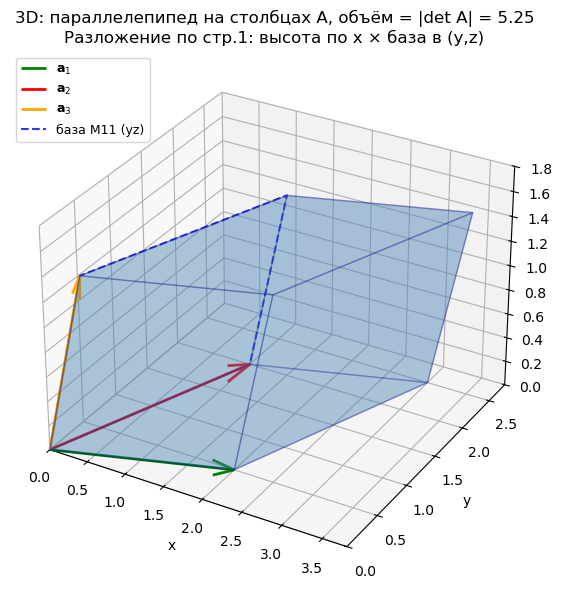

In [11]:
# Картинка: параллелепипед на столбцах A (объём = |det A|); «база» для разложения по строке 1 — в плоскости (y,z)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

A = np.array([[2,  1, 0.5],
              [0.5, 2, 0],
              [0,   0, 1.5]])
a1, a2, a3 = A[:, 0], A[:, 1], A[:, 2]
vol = abs(np.linalg.det(A))

# Вершины параллелепипеда O, a1, a2, a3, a1+a2, a1+a3, a2+a3, a1+a2+a3
O = np.zeros(3)
v = [O, a1, a2, a3, a1+a2, a1+a3, a2+a3, a1+a2+a3]
faces = [[v[0], v[1], v[4], v[2]], [v[0], v[1], v[5], v[3]], [v[0], v[2], v[6], v[3]],
         [v[1], v[4], v[7], v[5]], [v[2], v[4], v[7], v[6]], [v[3], v[5], v[7], v[6]]]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.add_collection3d(Poly3DCollection(faces, alpha=0.25, facecolor='steelblue', edgecolor='navy', linewidths=1))
ax.quiver(0, 0, 0, a1[0], a1[1], a1[2], color='green', arrow_length_ratio=0.12, linewidth=2, label=r'$\mathbf{a}_1$')
ax.quiver(0, 0, 0, a2[0], a2[1], a2[2], color='red', arrow_length_ratio=0.12, linewidth=2, label=r'$\mathbf{a}_2$')
ax.quiver(0, 0, 0, a3[0], a3[1], a3[2], color='orange', arrow_length_ratio=0.12, linewidth=2, label=r'$\mathbf{a}_3$')
# «База» в плоскости yz (столбцы 2 и 3 при x=0) — площадь = |M11|
ax.plot([0, a2[0], a2[0]+a3[0], a3[0], 0], [0, a2[1], a2[1]+a3[1], a3[1], 0], [0, a2[2], a2[2]+a3[2], a3[2], 0],
        'b--', linewidth=1.5, alpha=0.8, label='база M11 (yz)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc='upper left', fontsize=9)
ax.set_title(f'3D: параллелепипед на столбцах A, объём = |det A| = {vol:.2f}\nРазложение по стр.1: высота по x × база в (y,z)')
all_pts = np.array(v)
ax.set_xlim(0, all_pts[:, 0].max() + 0.3)
ax.set_ylim(0, all_pts[:, 1].max() + 0.3)
ax.set_zlim(0, all_pts[:, 2].max() + 0.3)
plt.tight_layout()
plt.show()